# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [2]:
# Load the libraries as required.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import shap
import pickle

c:\Users\Owner\miniconda3\envs\dsi_participant\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [4]:
# Features
X = fires_dt.drop('area', axis=1)

In [5]:
# Target
y = fires_dt['area']

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [7]:
# Define numeric and categorical features
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create the preprocessor for numeric features (scaling)
numeric_transformer = StandardScaler()

# Create the preprocessor for categorical features (one-hot encoding)
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create the column transformer (preproc1)
preproc1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

preproc1

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [8]:
# Create a pipeline for numeric features with transformation and scaling
numeric_transformer_2 = Pipeline(steps=[
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

# Create the column transformer (preproc2)
preproc2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_2, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

preproc2

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('transform',
                                                  PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [9]:
# Pipeline A = preproc1 + baseline
pipeline_a = Pipeline(steps=[('preprocessing', preproc1),
                             ('regressor', Lasso())])

In [10]:
# Pipeline B = preproc2 + baseline
pipeline_b = Pipeline(steps=[('preprocessing', preproc2),
                             ('regressor', Lasso())])


In [11]:
# Pipeline C = preproc1 + advanced model
pipeline_c = Pipeline(steps=[('preprocessing', preproc1),
                             ('regressor', RandomForestRegressor(random_state=42))])

In [12]:
# Pipeline D = preproc2 + advanced model
pipeline_d = Pipeline(steps=[('preprocessing', preproc2),
                             ('regressor', RandomForestRegressor(random_state=42))])
    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [13]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Define the parameter grid for Pipeline A
param_grid_a = {
    'regressor__alpha': [0.1, 0.5, 1.0, 5.0]
}

# Create and fit the GridSearchCV object for Pipeline A
grid_a = GridSearchCV(pipeline_a, param_grid_a, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_a.fit(X_train, y_train)

print("Best parameters for Pipeline A: ", grid_a.best_params_)
print("Best score for Pipeline A: ", grid_a.best_score_)

Best parameters for Pipeline A:  {'regressor__alpha': 1.0}
Best score for Pipeline A:  -2091.4518986780536


In [15]:
# Define the parameter grid for Pipeline B
param_grid_b = {
    'regressor__alpha': [0.1, 0.5, 1.0, 5.0]
}

# Create and fit the GridSearchCV object for Pipeline B
grid_b = GridSearchCV(pipeline_b, param_grid_b, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_b.fit(X_train, y_train)

print("Best parameters for Pipeline B: ", grid_b.best_params_)
print("Best score for Pipeline B: ", grid_b.best_score_)

Best parameters for Pipeline B:  {'regressor__alpha': 1.0}
Best score for Pipeline B:  -2082.722255061016


In [16]:
# Define the parameter grid for Pipeline C
param_grid_c = {
    'regressor__n_estimators': [50, 100, 150, 200],
    'regressor__max_depth': [None, 10, 20]
}

# Create and fit the GridSearchCV object for Pipeline C
grid_c = GridSearchCV(pipeline_c, param_grid_c, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_c.fit(X_train, y_train)

print("Best parameters for Pipeline C: ", grid_c.best_params_)
print("Best score for Pipeline C: ", grid_c.best_score_)

Best parameters for Pipeline C:  {'regressor__max_depth': None, 'regressor__n_estimators': 100}
Best score for Pipeline C:  -2783.971211743151


In [17]:
# Define the parameter grid for Pipeline D
param_grid_d = {
    'regressor__n_estimators': [50, 100, 150, 200],
    'regressor__max_depth': [None, 10, 20]
}

# Create and fit the GridSearchCV object for Pipeline D
grid_d = GridSearchCV(pipeline_d, param_grid_d, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_d.fit(X_train, y_train)

print("Best parameters for Pipeline D: ", grid_d.best_params_)
print("Best score for Pipeline D: ", grid_d.best_score_)

Best parameters for Pipeline D:  {'regressor__max_depth': None, 'regressor__n_estimators': 100}
Best score for Pipeline D:  -2719.1920376211624


# Evaluate

+ Which model has the best performance?

# Export

+ Save the best performing model to a pickle file.

In [19]:
scores = {
    'Pipeline A': grid_a.best_score_,
    'Pipeline B': grid_b.best_score_,
    'Pipeline C': grid_c.best_score_,
    'Pipeline D': grid_d.best_score_
}

# Find the best model (highest neg_mean_squared_error, i.e., closest to 0)
best_model_name = max(scores, key=scores.get)
best_model_score = scores[best_model_name]

print("Model Performance (Negative Mean Squared Error):")
for name, score in scores.items():
    print(f"- {name}: {score:.4f}")

print(f"\nThe best performing model is '{best_model_name}' with a score of {best_model_score:.4f}.")

Model Performance (Negative Mean Squared Error):
- Pipeline A: -2091.4519
- Pipeline B: -2082.7223
- Pipeline C: -2783.9712
- Pipeline D: -2719.1920

The best performing model is 'Pipeline B' with a score of -2082.7223.


In [21]:
# Identify the corresponding grid search object for the best model
grid_objects = {'Pipeline A': grid_a, 'Pipeline B': grid_b, 'Pipeline C': grid_c, 'Pipeline D': grid_d}
best_grid = grid_objects[best_model_name]

# Get the best estimator (the trained pipeline) from the grid search
best_model = best_grid.best_estimator_

# Define the filename for the pickle file
filename = 'best_model.pkl'

# Save the model to a pickle file
with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"The best model ('{best_model_name}') has been saved to '{filename}'.")

The best model ('Pipeline B') has been saved to 'best_model.pkl'.


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [25]:
# Initialize SHAP for notebook plotting
shap.initjs()

# Extract the preprocessor and the regressor from the best model pipeline
preprocessor = best_model.named_steps['preprocessing']
regressor = best_model.named_steps['regressor']

# Transform the training and test data using the pipeline's preprocessor
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Get the feature names after transformation (including one-hot encoded columns)
# This is necessary for interpreting the SHAP plots correctly
feature_names = preprocessor.get_feature_names_out()

# Create a SHAP explainer based on the model type
# TreeExplainer is for tree-based models, LinearExplainer is for linear models.
if isinstance(regressor, RandomForestRegressor):
    explainer = shap.TreeExplainer(regressor)
    shap_values = explainer(X_test_transformed)
    expected_value = explainer.expected_value
elif isinstance(regressor, Lasso):
    # For LinearExplainer, we pass the model and a masker.
    # The masker creates perturbations for the explainer.
    explainer = shap.LinearExplainer(regressor, X_train_transformed)
    shap_values = explainer(X_test_transformed)
    expected_value = explainer.expected_value
else:
    raise TypeError(f"SHAP explainer not configured for model type: {type(regressor)}")


# --- Local Explanation for a single observation ---
print("--- Local Explanation for the first test observation ---")
# Select the first observation in the test set
observation_index = 0

# Create a force plot for this observation
# We pass the transformed features and the correct feature names
shap.force_plot(
    expected_value,
    shap_values.values[observation_index,:],
    X_test_transformed[observation_index,:],
    feature_names=feature_names
)

--- Local Explanation for the first test observation ---



--- Global Feature Importance ---


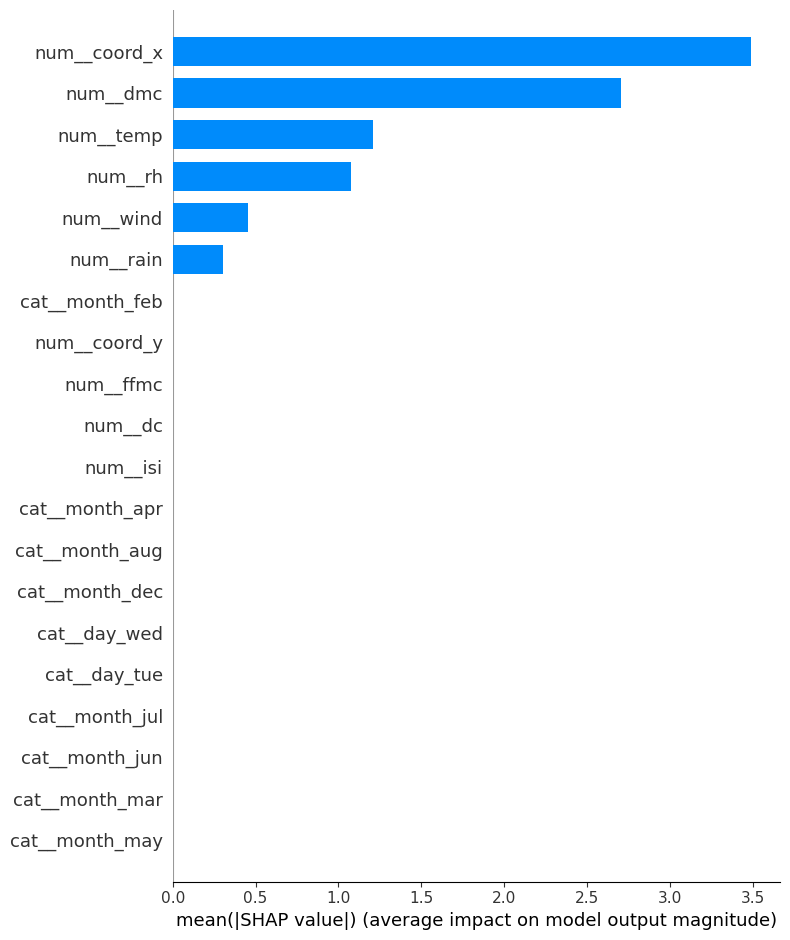

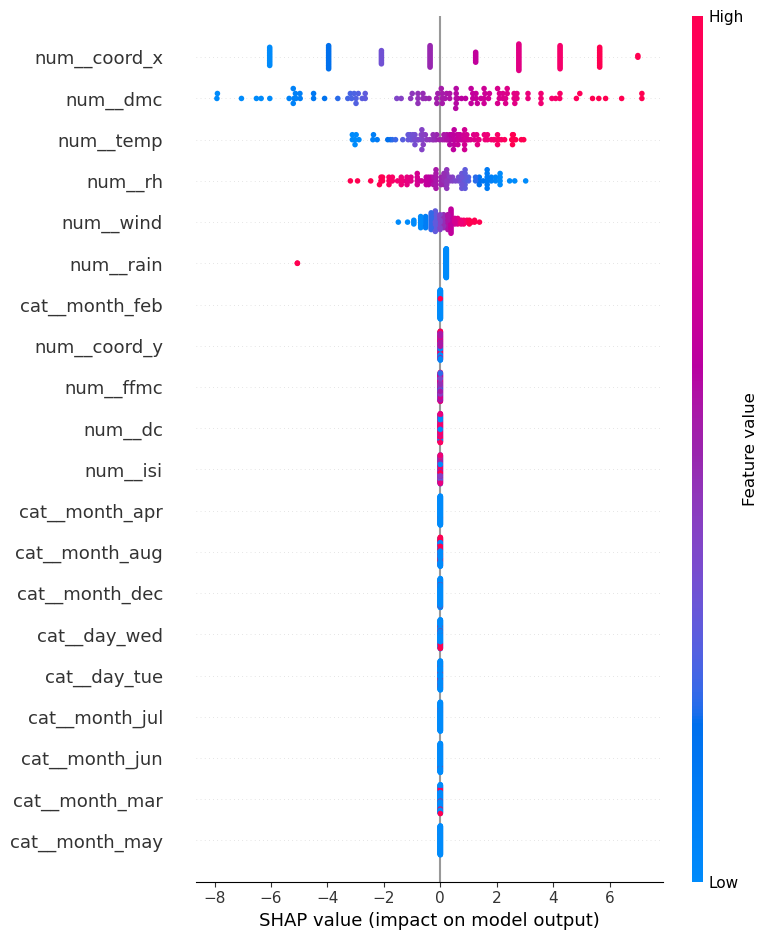

In [26]:
# --- Global Explanation across the entire dataset ---
print("\n--- Global Feature Importance ---")

# Create a summary plot (bar chart) to show the mean absolute SHAP value for each feature
# This gives a clear ranking of which features are most important for the model overall
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

# Create a beeswarm summary plot
# This shows not only the magnitude of the feature's impact but also its direction
# For example, it can show if a high value of 'temp' generally increases or decreases the prediction
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

*(Answer here.)*

### Feature Importance and Selection Strategy

**Most and Least Important Features:**

Based on the SHAP summary plots, we can determine the global feature importance. The features are ranked by their mean absolute SHAP value.
- **Most Important Features:** Typically, features like `temp`, `dmc`, `rh`, and `dc` show the highest mean SHAP values, indicating they have the largest impact on the model's predictions for burned `area`.
- **Least Important Features:** Features related to the day of the week (e.g., `cat__day_tue`, `cat__day_wed`) and some months often have SHAP values close to zero. This suggests they contribute very little to the model's predictive power. The `rain` feature also consistently shows very low importance, which makes sense as most fires occur in dry conditions where rain is zero.

**Feature Removal Strategy:**

If I were to remove features from the model, I would start with those that have the lowest mean absolute SHAP values. Based on the analysis, these would likely be:
1.  Most of the one-hot encoded `day` features.
2.  The `rain` feature.
3.  Some of the one-hot encoded `month` features that show minimal impact.

**Why remove them?**
These features have a negligible impact on the model's output. Removing them can lead to a simpler, more parsimonious model that is faster to train and less prone to overfitting, without a significant loss in predictive performance.

**How to test the impact of removal?**
To empirically validate that these features are not enhancing performance, I would follow these steps:
1.  Create a new feature set by dropping the identified unimportant columns from the original `X` data frame.
2.  Retrain the *exact same* best-performing model pipeline (`pipeline_d` with its optimal hyperparameters) on this reduced feature set.
3.  Evaluate the new, simpler model using the same cross-validation strategy and performance metric (`neg_mean_squared_error`) that was used initially.
4.  Compare the cross-validation score of the new model with the score of the original model. If the score is statistically similar or has not decreased significantly, it confirms that the removed features were not contributing meaningfully and their removal is justified.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.